In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import PchipInterpolator
import gc

from pathlib import Path

In [2]:
CURRENT_DIR = Path().resolve().parent.parent
RAW_DATA_DIR = CURRENT_DIR / "data" / "raw" 

files = {
    'DGS1MO.csv': ('1M', 1/12),
    'DGS3MO.csv': ('3M', 3/12),
    'DGS6MO.csv': ('6M', 6/12),
    'DGS1.csv':   ('1Y', 1),
    'DGS2.csv':   ('2Y', 2),
    'DGS3.csv':   ('3Y', 3),
    'DGS5.csv':   ('5Y', 5)
}

dfs = []
for f_name, (label, maturity) in files.items():
    file_path = RAW_DATA_DIR / f_name
    
    df_temp = pd.read_csv(file_path, parse_dates=['observation_date'], na_values='.')
    df_temp = df_temp.rename(columns={'observation_date': 'date', df_temp.columns[1]: 'yield'})
    df_temp['yield'] = pd.to_numeric(df_temp['yield']) / 100
    
    df_temp = df_temp.set_index('date').sort_index()
    df_temp = df_temp.ffill()
    
    dfs.append(df_temp['yield'].rename(label))

df_yields = pd.concat(dfs, axis=1).dropna()
maturities = np.array(list(files.values()))

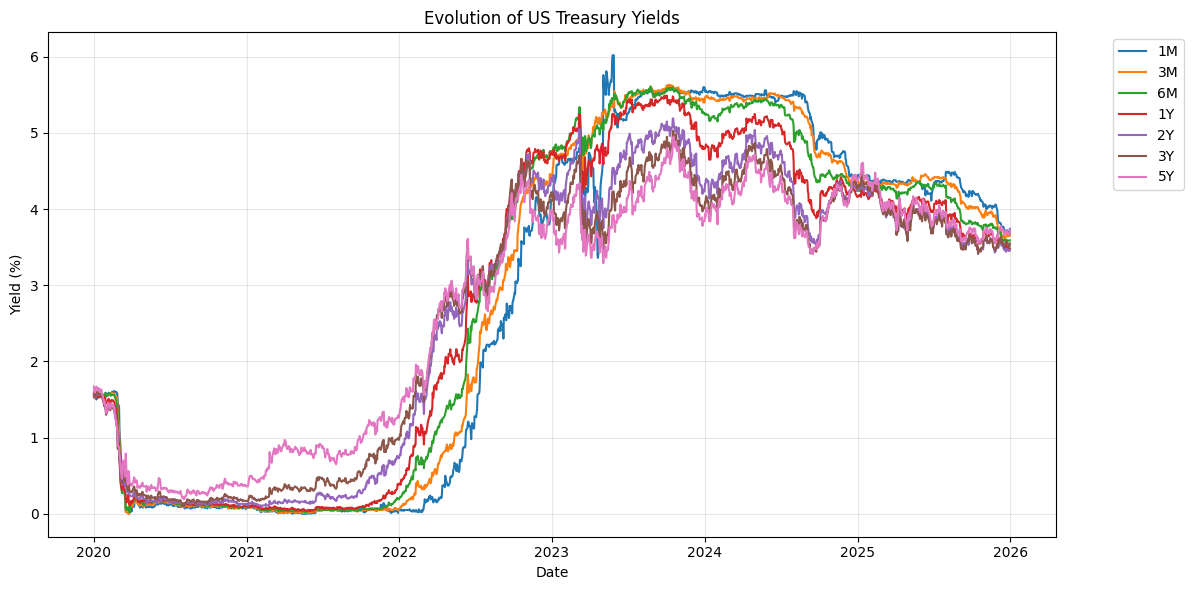

In [3]:
plt.figure(figsize=(12, 6))
for col in df_yields.columns:
    plt.plot(df_yields.index, df_yields[col] * 100, label=col)

plt.title("Evolution of US Treasury Yields")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

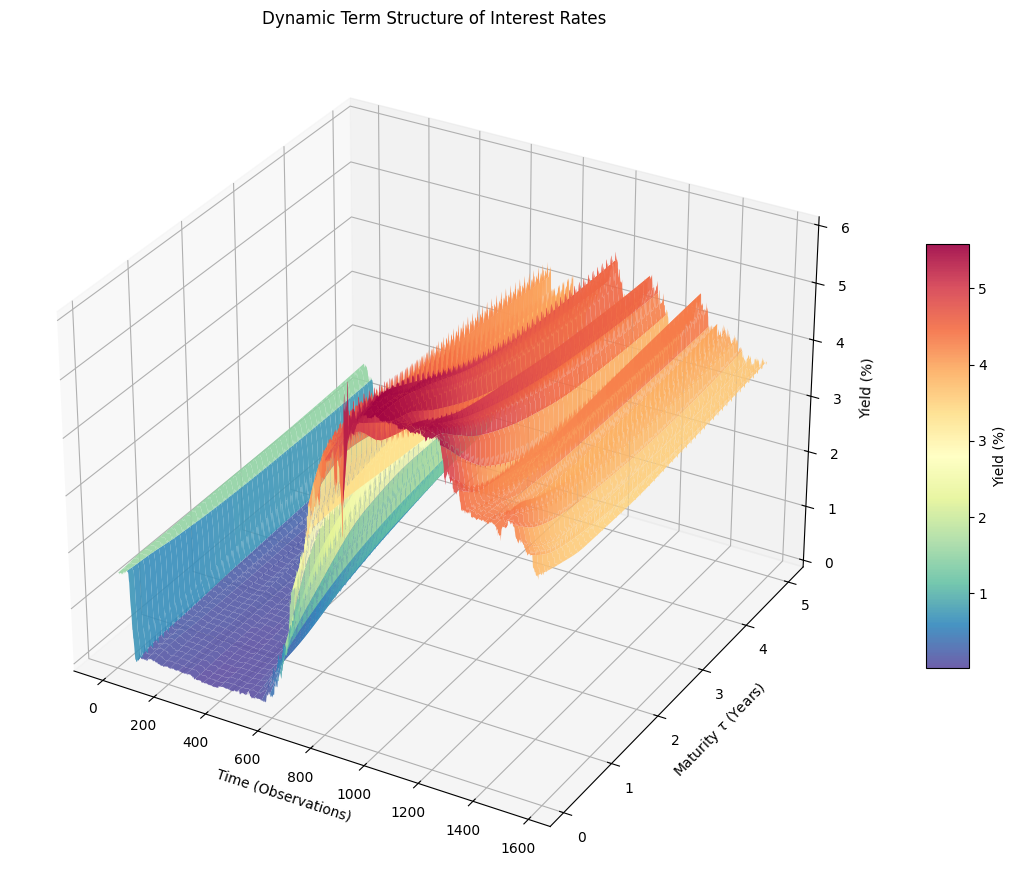

In [4]:
maturities = np.array([v[1] for v in files.values()])

tau_grid = np.linspace(maturities.min(), maturities.max(), 50)
surface_z = []

for i in range(len(df_yields)):
    y = df_yields.iloc[i].values
    interp = PchipInterpolator(maturities, y, extrapolate=True)
    surface_z.append(interp(tau_grid))

surface_z = np.array(surface_z)

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(np.arange(len(df_yields)), tau_grid)
Z = surface_z.T 

surf = ax.plot_surface(X, Y, Z * 100, cmap='Spectral_r', edgecolor='none', alpha=0.9)

ax.set_title("Dynamic Term Structure of Interest Rates")
ax.set_xlabel("Time (Observations)")
ax.set_ylabel("Maturity $\\tau$ (Years)")
ax.set_zlabel("Yield (%)")

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Yield (%)')
ax.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.show()

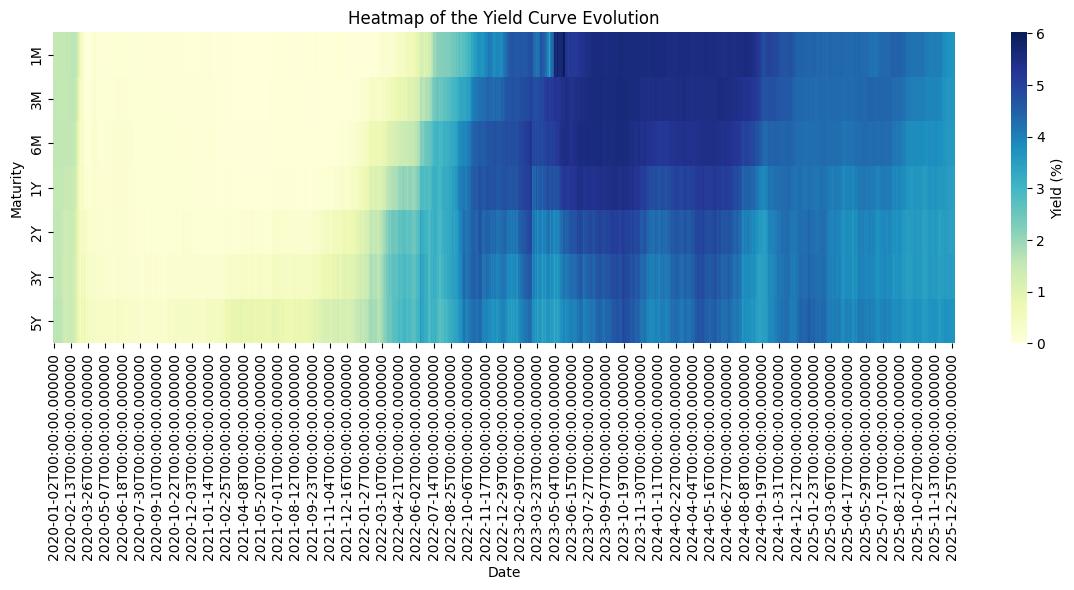

In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_yields.T * 100, cmap="YlGnBu", cbar_kws={'label': 'Yield (%)'})
plt.title("Heatmap of the Yield Curve Evolution")
plt.xlabel("Date")
plt.ylabel("Maturity")
plt.tight_layout()

In [6]:
PARQUET_FILE = RAW_DATA_DIR / "options_surfaces_data.parquet"

lazy_df = pl.scan_parquet(PARQUET_FILE)

In [7]:
INDEX_ETFS = ["SPY", "QQQ", "IWM", "TLT", "GLD"]

lazy_df = lazy_df.with_columns([
    pl.col("expiration").str.to_datetime().dt.truncate("1d").alias("expiry_base")
]).with_columns([
    pl.when(pl.col("underlying_symbol").is_in(INDEX_ETFS))
    .then(pl.col("expiry_base") + pl.duration(hours=16, minutes=15))
    .otherwise(pl.col("expiry_base") + pl.duration(hours=16))
    .alias("expiration")
]).drop("expiry_base")

lazy_df = lazy_df.with_columns([
    pl.col("quote_datetime").str.to_datetime()
]).with_columns([
    (
        (pl.col("expiration") - pl.col("quote_datetime")).dt.total_seconds() 
        / (365.25 * 24 * 3600)
    )
    .cast(pl.Float32)  # Critical memory optimization
    .alias("tau")
])

lazy_df = lazy_df.filter(pl.col("tau") > 0)

df = lazy_df.collect(engine="streaming")
gc.collect()

print(df.select(["underlying_symbol", "expiration", "quote_datetime", "tau"]).head())

shape: (5, 4)
┌───────────────────┬─────────────────────┬─────────────────────┬──────────┐
│ underlying_symbol ┆ expiration          ┆ quote_datetime      ┆ tau      │
│ ---               ┆ ---                 ┆ ---                 ┆ ---      │
│ str               ┆ datetime[μs]        ┆ datetime[μs]        ┆ f32      │
╞═══════════════════╪═════════════════════╪═════════════════════╪══════════╡
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
└───────────────────┴─────────────────────┴─────────────────────┴──────────┘


In [8]:
def apply_rate_optimized(polars_df, df_yields, maturities):

    pdf = polars_df.select([
        pl.col("quote_datetime").dt.truncate("1d").alias("date_only"),
        pl.col("tau")
    ]).to_pandas()
    
    df_yields.index = pd.to_datetime(df_yields.index).normalize()

    rate_results = np.empty(len(pdf), dtype=np.float32)

    for date, group_indices in pdf.groupby('date_only').groups.items():
        idx = df_yields.index.get_indexer([date], method='pad')[0]
        if idx == -1: 
            rate_results[group_indices] = np.nan
            continue
        
        y_curve = df_yields.iloc[idx].values.astype(float)
        taus = pdf.loc[group_indices, 'tau'].values
        
        interp = PchipInterpolator(maturities, y_curve, extrapolate=True)
        y_interpolated = interp(taus)
        
        rate_results[group_indices] = np.log(1 + y_interpolated)
        
    return rate_results

In [9]:
rates = apply_rate_optimized(df, df_yields, maturities)
df = df.with_columns(pl.Series("rate", rates))

del rates
gc.collect()

0

In [10]:
PROCESSED_DATA_DIR = CURRENT_DIR / "data" / "processed" 
OUTPUT_FILE = PROCESSED_DATA_DIR / "options_surfaces_data.parquet"

df.write_parquet(OUTPUT_FILE, compression="zstd")